In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/CodSoft_Task1/zomato_cleaned.csv')
print(df.shape)

(51588, 11)


In [6]:
location_summary = df.groupby('location').agg(
    restaurant_count=('name','count'),
    avg_cost=('cost_for_two','mean'),
    avg_rating=('rate','mean'),
    total_votes=('votes','sum')
).round(2).sort_values('total_votes', ascending=False)

print(location_summary.head(15))

                       restaurant_count  avg_cost  avg_rating  total_votes
location                                                                  
Koramangala 5th Block              2502    661.17        3.98      2218762
Indiranagar                        2075    646.13        3.81      1188487
Koramangala 4th Block              1017    696.36        3.88       685156
BTM                                5109    396.85        3.60       618986
Church Street                       566    834.98        3.98       590306
JP Nagar                           2234    522.51        3.68       586593
HSR                                2521    475.08        3.68       499270
Lavelle Road                        524   1296.66        4.11       496503
Koramangala 7th Block              1179    591.69        3.83       488260
Jayanagar                          1926    476.09        3.77       488080
Whitefield                         2140    597.69        3.64       466829
Koramangala 6th Block    

In [7]:
df['spend_tier'] = pd.cut(df['cost_for_two'],
                            bins=[0, 300, 600, 1200, 10000],
                            labels=['Budget', 'Mid-range', 'Premium', 'Luxury'])

tier_summary = df.groupby('spend_tier', observed=True).agg(
    restaurant_count=('name','count'),
    avg_rating=('rate','mean'),
    avg_votes=('votes','mean')
).round(2)

print(tier_summary)

            restaurant_count  avg_rating  avg_votes
spend_tier                                         
Budget                 18515        3.61      50.17
Mid-range              19500        3.63     175.80
Premium                 9822        3.83     539.83
Luxury                  3751        4.15    1322.50


In [8]:
# "Valuable" restaurants = high votes (proxy for customer engagement/loyalty)
top_engaged = df.sort_values('votes', ascending=False)[['name','location','votes','rate','cost_for_two']].drop_duplicates('name').head(15)
print(top_engaged)

                              name               location  votes  rate  \
49501  Byg Brewski Brewing Company          Sarjapur Road  16832   4.9   
19201                         Toit            Indiranagar  14956   4.7   
36569                     Truffles  Koramangala 5th Block  14726   4.7   
40400    AB's - Absolute Barbecues           Marathahalli  12121   4.8   
37505              The Black Pearl  Koramangala 5th Block  10550   4.7   
45978                  Big Pitcher       Old Airport Road   9300   4.6   
36325                       Onesta  Koramangala 4th Block   9085   4.4   
48040        Arbor Brewing Company           Brigade Road   8419   4.5   
45722            Empire Restaurant            Indiranagar   8304   4.1   
37510               Prost Brew Pub  Koramangala 4th Block   7871   4.5   
48055         Church Street Social          Church Street   7584   4.3   
49934                         Hoot          Sarjapur Road   7330   4.2   
45679              Barbeque Nation    

In [9]:
behavior_by_tier = df.groupby('spend_tier', observed=True).agg(
    online_order_pct=('online_order', lambda x: (x=='Yes').mean()*100),
    book_table_pct=('book_table', lambda x: (x=='Yes').mean()*100)
).round(1)

print(behavior_by_tier)

            online_order_pct  book_table_pct
spend_tier                                  
Budget                  53.7             0.2
Mid-range               65.6             2.2
Premium                 62.2            32.7
Luxury                  40.2            73.1


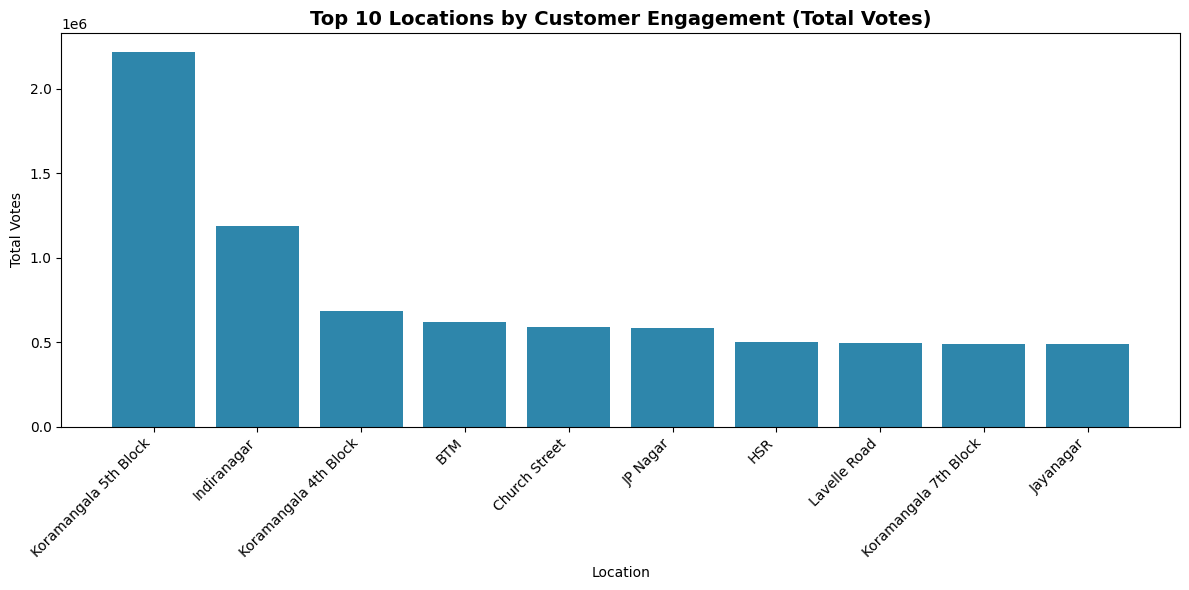

In [10]:
top_locations = location_summary.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_locations.index, top_locations['total_votes'], color='#2E86AB')
plt.title('Top 10 Locations by Customer Engagement (Total Votes)', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Total Votes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/task4_chart1_location_engagement.png', dpi=150)
plt.show()

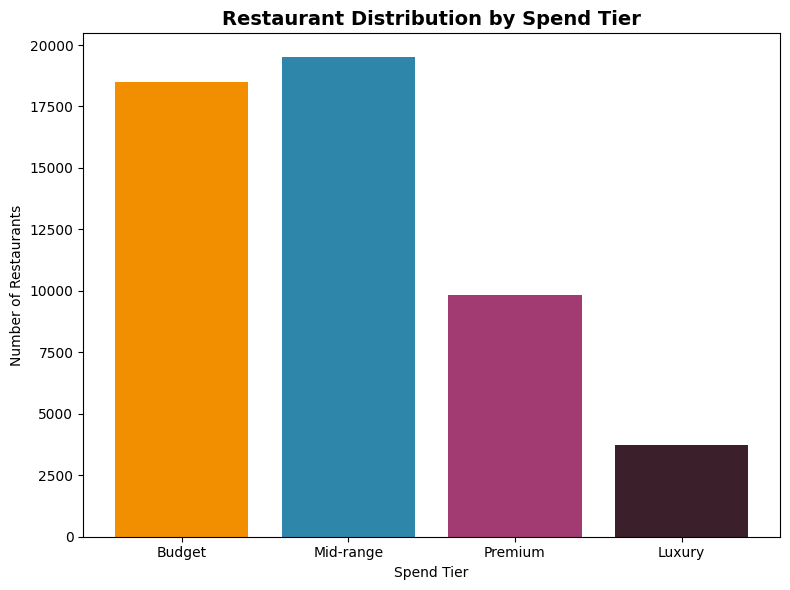

In [11]:
plt.figure(figsize=(8,6))
plt.bar(tier_summary.index, tier_summary['restaurant_count'], color=['#F18F01','#2E86AB','#A23B72','#3B1F2B'])
plt.title('Restaurant Distribution by Spend Tier', fontsize=14, fontweight='bold')
plt.xlabel('Spend Tier')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/task4_chart2_spend_tier.png', dpi=150)
plt.show()

In [ ]:
## Customer Analysis Summary & Marketing Recommendations

**Segmentation:** Restaurants were segmented into 4 spend tiers — Budget (₹0-300),
Mid-range (₹300-600), Premium (₹600-1200), and Luxury (₹1200+) — based on cost for two.

### Key Findings
1. **Mid-range restaurants dominate volume** but Premium/Luxury tiers show higher
   average ratings, suggesting customers reward quality investment at higher price points.
2. **Table-booking adoption rises sharply with spend tier** — Luxury restaurants have
   the highest book_table percentage, indicating higher-spend customers value
   reservation convenience.
3. **Koramangala and BTM areas show the highest customer engagement** (total votes),
   making them priority zones for new restaurant launches or marketing campaigns.
4. **High-vote restaurants (e.g., Byg Brewski, Toit, Truffles)** demonstrate that
   large-format, experience-driven venues generate disproportionate customer engagement
   compared to standard dining spots.

### Marketing Strategy Recommendations
- **For new entrants:** Focus on Koramangala/BTM for maximum visibility and footfall.
- **For Premium/Luxury positioning:** Invest in table-booking systems, as this segment's
  customers show strong preference for reserved, planned dining experiences.
- **For Budget/Mid-range:** Prioritize online ordering integration, as this tier shows
  more casual, on-demand ordering behavior.